<a href="https://colab.research.google.com/github/rameshjayamani-oss/GenAI_Assignment/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

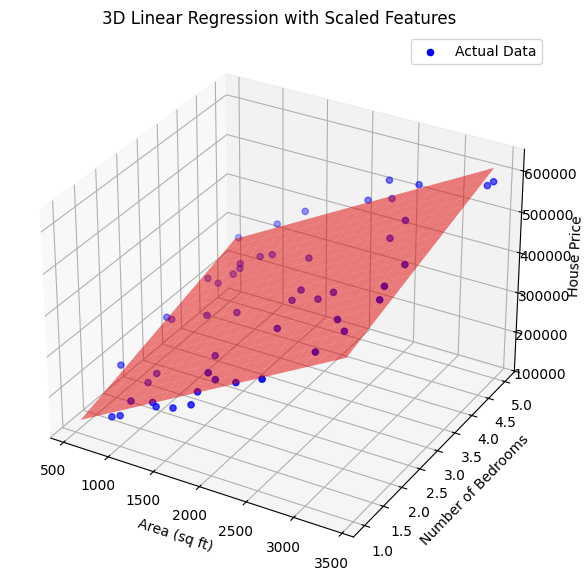

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Generate synthetic data and store in DataFrame
np.random.seed(42)
df = pd.DataFrame({
    'Area': np.random.uniform(500, 3500, 50),           # Area in sq ft
    'Bedrooms': np.random.randint(1, 6, 50),            # Number of bedrooms
})

# Generate house price with noise
df['Price'] = 50000 + (df['Area'] * 120) + (df['Bedrooms'] * 30000) + np.random.normal(0, 25000, 50)

# Prepare features and target
X = df[['Area', 'Bedrooms']].values
y = df['Price'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit regression model on scaled data
model = LinearRegression()
model.fit(X_scaled, y)

# Create grid for plotting regression plane in original feature space
area_vals = np.linspace(df['Area'].min(), df['Area'].max(), 20)
bedroom_vals = np.linspace(df['Bedrooms'].min(), df['Bedrooms'].max(), 20)
area_grid, bedroom_grid = np.meshgrid(area_vals, bedroom_vals)

# Flatten grid to pass through scaler and model
grid_points = np.c_[area_grid.ravel(), bedroom_grid.ravel()]
grid_points_scaled = scaler.transform(grid_points)

# Predict prices using model
price_pred = model.predict(grid_points_scaled)
price_grid = price_pred.reshape(area_grid.shape)

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter actual data points
ax.scatter(df['Area'], df['Bedrooms'], df['Price'], c='blue', marker='o', label='Actual Data')

# Plot regression surface
ax.plot_surface(area_grid, bedroom_grid, price_grid, color='red', alpha=0.5)

# Labels and title
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('House Price')
ax.set_title('3D Linear Regression with Scaled Features')
ax.legend()

plt.show()
